In [14]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\dimol\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\dimol\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\dimol\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\dimol\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import pivot_table
from datetime import date

In [16]:
# window에 있는 글꼴로 한글 폰트 설정하기
import matplotlib
import matplotlib.font_manager as fm

font_path = "C:\\Windows\\Fonts\\gulim.ttc"
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()
matplotlib.rc('font', family=font_name)
plt.rc('axes', unicode_minus=False)

In [17]:
bank_df = pd.read_csv('data/cleaned_bank_data.csv')

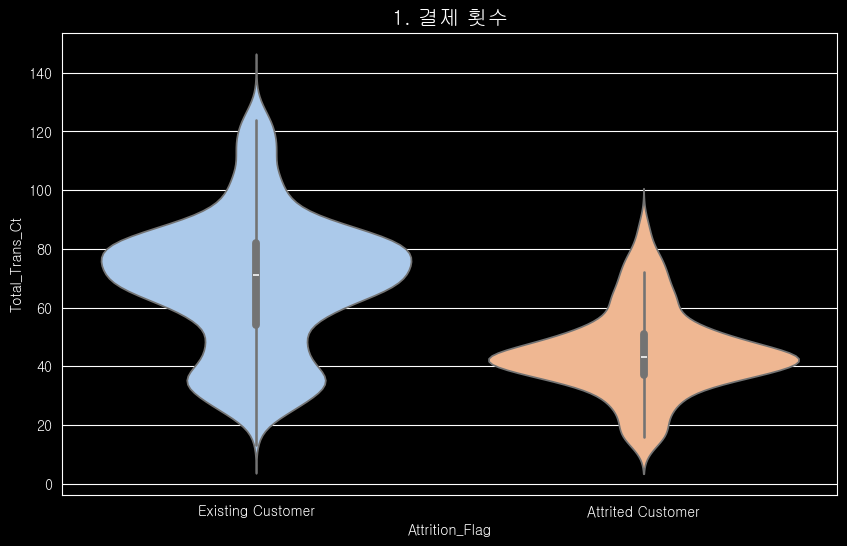

In [18]:
# Total_Trans_Ct(결제 횟수) 시각화
plt.figure(figsize=(10, 6))
sns.violinplot(data=bank_df, x='Attrition_Flag', y='Total_Trans_Ct',
               hue='Attrition_Flag', palette='pastel', legend=False)
plt.title('1. 결제 횟수', fontsize=15)
plt.show()

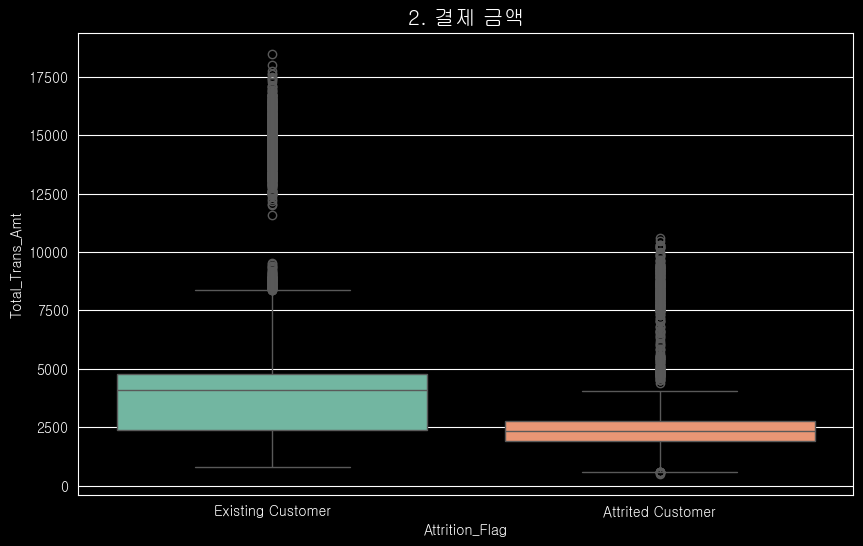

In [19]:
# Total_Trans_Amt(소모 금액) 시각화
plt.figure(figsize=(10, 6))
sns.boxplot(data=bank_df, x='Attrition_Flag', y='Total_Trans_Amt',
            hue='Attrition_Flag', palette='Set2', legend=False)
plt.title('2. 결제 금액', fontsize=15)
plt.show()

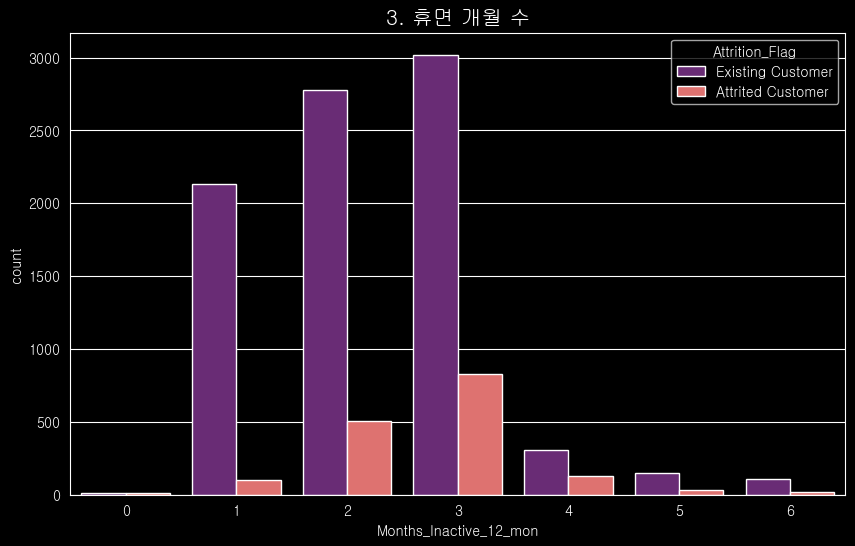

In [20]:
# Months_Inactive_12_mon(지난 12달간 카드 휴면이었던 달 수)
plt.figure(figsize=(10, 6))
sns.countplot(data=bank_df, x='Months_Inactive_12_mon', hue='Attrition_Flag', palette='magma')
plt.title('3. 휴면 개월 수', fontsize=15)
plt.show()

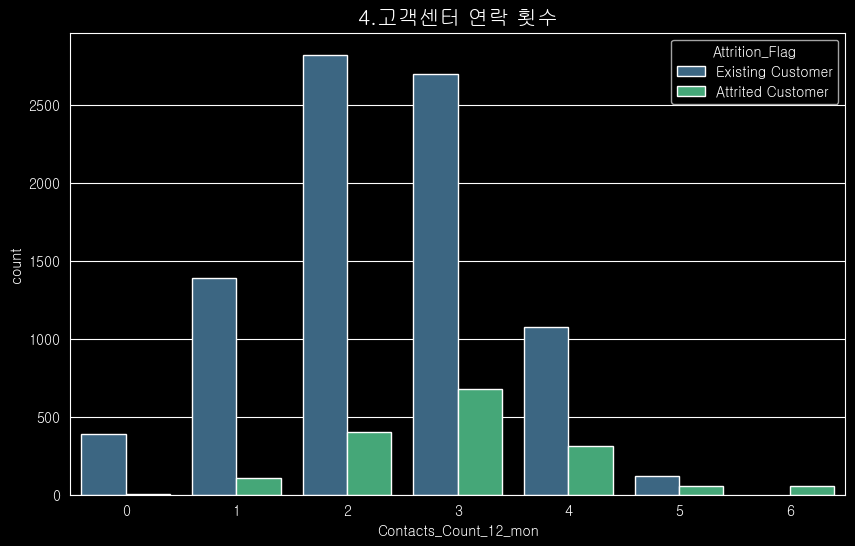

In [21]:
# Contacts_Count_12_mon(고객센터 연락 횟수)
plt.figure(figsize=(10, 6))
sns.countplot(data=bank_df, x='Contacts_Count_12_mon', hue='Attrition_Flag', palette='viridis')
plt.title('4.고객센터 연락 횟수', fontsize=15)
plt.show()

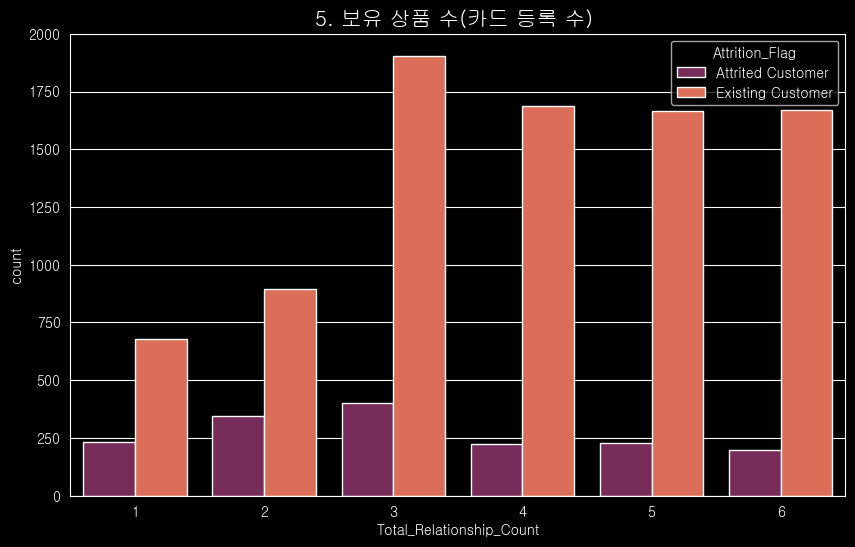

In [22]:
# Total_Relationship_Count(몇 장의 카드를 등록했는지)
plt.figure(figsize=(10, 6))
# 상품 개수가 적을 때(1~2개), 해지자 막대 비율이 더 큰지 확인!
sns.countplot(data=bank_df, x='Total_Relationship_Count', hue='Attrition_Flag', palette='rocket')
plt.title('5. 보유 상품 수(카드 등록 수) ', fontsize=15)
plt.show()

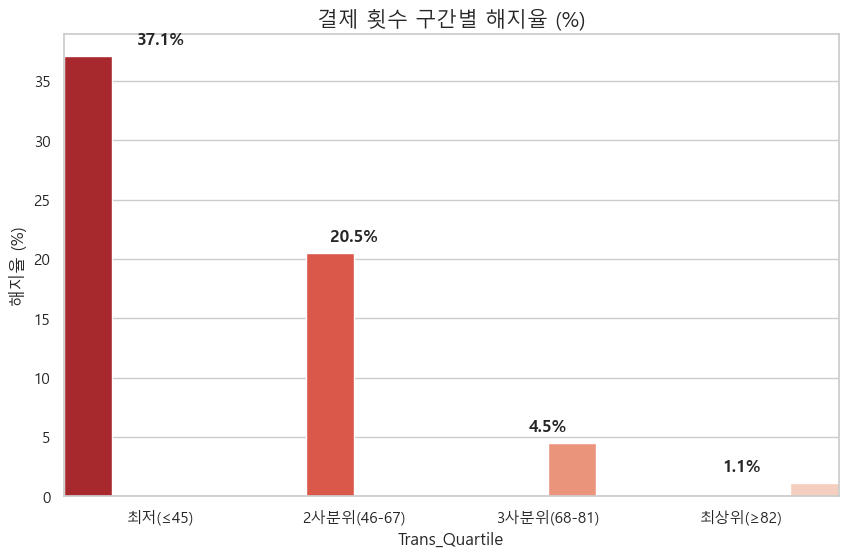

In [34]:
# 거래건수 사분위별 이탈률 바차트
# 1. 결제 횟수 구간별 해지율 계산
bins = [0, 45, 67, 81, bank_df['Total_Trans_Ct'].max()]
labels = ['최저(≤45)', '2사분위(46-67)', '3사분위(68-81)', '최상위(≥82)']
bank_df['Trans_Quartile'] = pd.cut(bank_df['Total_Trans_Ct'], bins=bins, labels=labels)
churn_rate_by_ct = bank_df.groupby('Trans_Quartile', observed=False)['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').mean() * 100
)

# 2. 바차트
plt.figure(figsize=(10, 6))
sns.barplot(
    x=churn_rate_by_ct.index,
    y=churn_rate_by_ct.values,
    hue=churn_rate_by_ct.index,
    palette='Reds_r',
    legend=False,
    width=1,
    native_scale=True
)

# 3. 수치 표시 및 타이틀 설정
for i, val in enumerate(churn_rate_by_ct.values):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('결제 횟수 구간별 해지율 (%)', fontsize=15)
plt.ylabel('해지율 (%)')
plt.show()

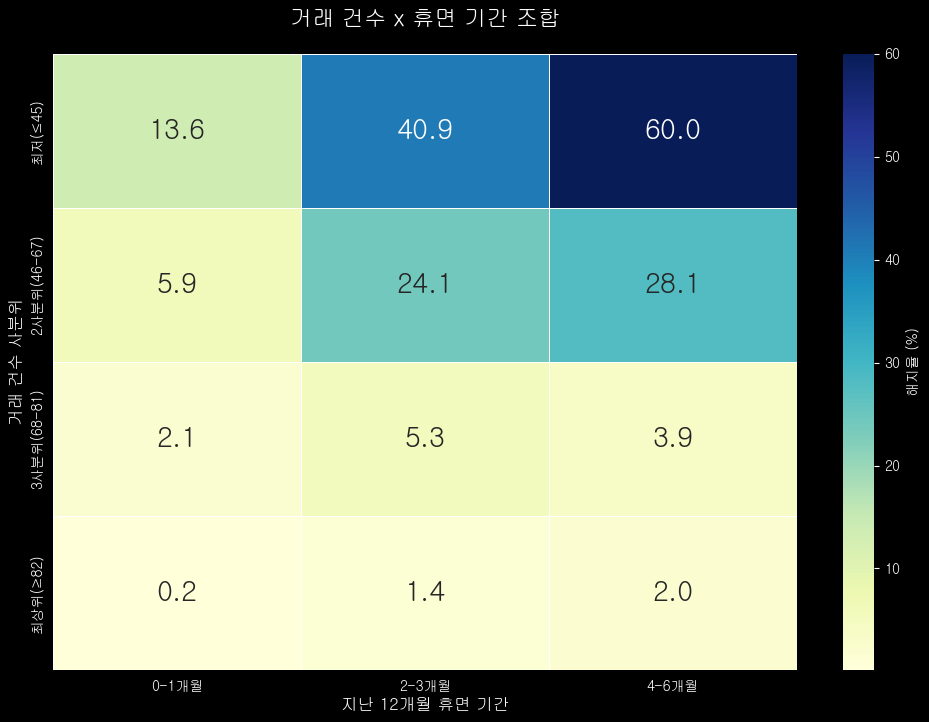

In [24]:
# 사용량 x 비활성 히트맵
# 1 거래 건수 사분위 그룹 생성
ct_bins = [0, 45, 67, 81, bank_df['Total_Trans_Ct'].max()]
ct_labels = ['최저(≤45)', '2사분위(46-67)', '3사분위(68-81)', '최상위(≥82)']
bank_df['Trans_Quartile'] = pd.cut(bank_df['Total_Trans_Ct'], bins=ct_bins, labels=ct_labels)

# 2 비활성 기간 그룹 생성
inact_bins = [-1, 1, 3, 6]
inact_labels = ['0-1개월', '2-3개월', '4-6개월']
bank_df['Inactive_Grp'] = pd.cut(bank_df['Months_Inactive_12_mon'], bins=inact_bins, labels=inact_labels)

# 3. 피벗 테이블 생성
heatmap_data = bank_df.pivot_table(
    index='Trans_Quartile',
    columns='Inactive_Grp',
    values='Attrition_Flag',
    aggfunc=lambda x: (x == 'Attrited Customer').mean() * 100,
    observed=False
)

# 4. 히트맵 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap='YlGnBu',
    linewidths=.5,
    cbar_kws={'label': '해지율 (%)'},
    annot_kws={"size": 20, "weight": "bold"}
)

plt.title('거래 건수 x 휴면 기간 조합', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('지난 12개월 휴면 기간', fontsize=12)
plt.ylabel('거래 건수 사분위', fontsize=12)
plt.show()

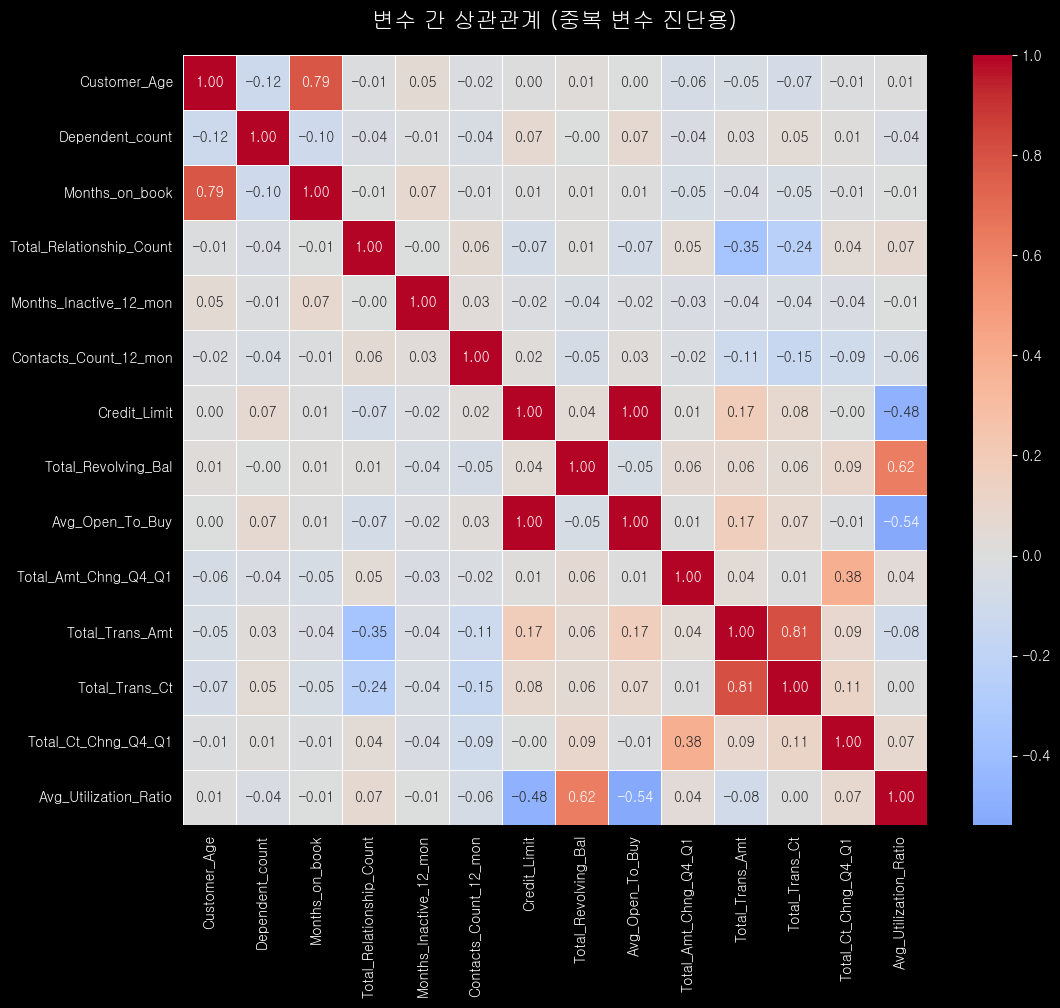

In [25]:
# 수치형 데이터만 골라서 상관관계 계산
numeric_df = bank_df.select_dtypes(include=['float64', 'int64']).drop(columns=['CLIENTNUM'], errors='ignore')
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=.5)

plt.title('변수 간 상관관계 (중복 변수 진단용)', fontsize=16, fontweight='bold', pad=20)
plt.show()

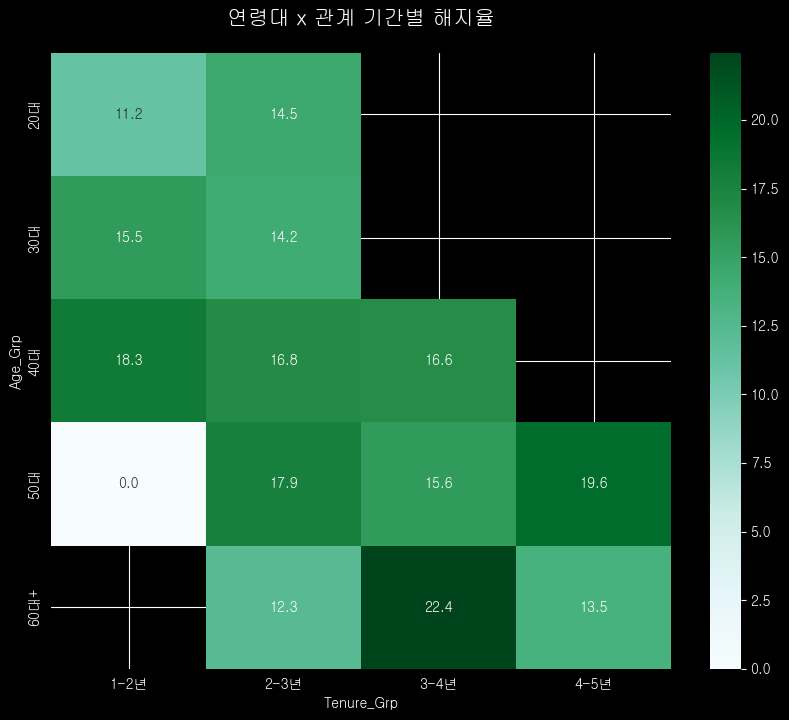

In [26]:
# 연령대와 관계기간(개월) 그룹화
bank_df['Age_Grp'] = pd.cut(bank_df['Customer_Age'], bins=[20, 30, 40, 50, 60, 70], labels=['20대', '30대', '40대', '50대', '60대+'])
bank_df['Tenure_Grp'] = pd.cut(bank_df['Months_on_book'], bins=[0, 12, 24, 36, 48, 60], labels=['1년이하', '1-2년', '2-3년', '3-4년', '4-5년'])

cohort_data = bank_df.pivot_table(
    index='Age_Grp', columns='Tenure_Grp', values='Attrition_Flag',
    aggfunc=lambda x: (x == 'Attrited Customer').mean() * 100, observed=False
)

plt.figure(figsize=(10, 8))
sns.heatmap(cohort_data, annot=True, fmt=".1f", cmap='BuGn')
plt.title('연령대 x 관계 기간별 해지율', fontsize=15, fontweight='bold', pad=20)
plt.show()